
# Dynamic Programming for MDPs — English Comments
**Updated:** 2025-08-24 (UTC)

This notebook implements three classic **Dynamic Programming (DP)** methods on a 4×4 Gridworld MDP, with clear English comments throughout:

- **Value Function Evaluation** (iterative policy evaluation)  
- **Policy Iteration** (alternating evaluation and improvement)  
- **Value Iteration** (Bellman optimality updates)  

Goal: make the mechanics of *value updates*, *policy improvement*, and *convergence criteria* easy to follow.


## 1. Setup

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# Pretty printing for arrays
np.set_printoptions(precision=3, suppress=True)



## 2. Gridworld MDP

A minimal 4×4 Gridworld:

- States `s ∈ {0..15}` in row-major order  
- Actions `a ∈ {0:up, 1:right, 2:down, 3:left}`  
- Terminal states: top-left `s=0` and bottom-right `s=15`  
- Reward `-1` per step; `0` at terminal states  
- Discount factor `γ ∈ (0,1)`  


In [11]:

# Action constants (improves readability)
UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
ACTIONS = [UP, RIGHT, DOWN, LEFT]

def to_s(r: int, c: int, n: int = 4) -> int:
    """Map (row, col) to a flat state index s."""
    return r * n + c

def to_rc(s: int, n: int = 4) -> tuple[int, int]:
    """Map a flat state index s back to (row, col)."""
    return divmod(s, n)

def step_gridworld(s: int, a: int, n: int = 4) -> tuple[int, float, bool]:
    """One deterministic transition in the gridworld.
    Args:
        s: current state index
        a: action (0:up, 1:right, 2:down, 3:left)
        n: grid size (default 4)
    Returns:
        s2: next state
        r: immediate reward (-1 per step, 0 at terminal)
        done: whether the next state is terminal
    """
    # Terminal states are absorbing (remain there with reward 0)
    if s == 0 or s == n*n - 1:
        return s, 0.0, True

    r, c = to_rc(s, n)
    # Clamp movement to grid bounds; hitting a wall leaves you in place
    if a == UP:
        r2, c2 = max(r - 1, 0), c
    elif a == RIGHT:
        r2, c2 = r, min(c + 1, n - 1)
    elif a == DOWN:
        r2, c2 = min(r + 1, n - 1), c
    else:  # LEFT
        r2, c2 = r, max(c - 1, 0)

    s2 = to_s(r2, c2, n)
    done = (s2 == 0 or s2 == n*n - 1)
    reward = 0.0 if done else -1.0
    return s2, reward, done

def build_gridworld(n: int = 4):
    """Build transition dict P[s][a] = [(prob, s', r, done), ...].
    Deterministic environment: one outcome per (s,a) with prob=1.
    """
    S = n * n      # number of states
    A = 4          # number of actions
    P = {s: {a: [] for a in range(A)} for s in range(S)}
    for s in range(S):
        for a in range(A):
            s2, r, done = step_gridworld(s, a, n)
            P[s][a] = [(1.0, s2, r, done)]
    return P, S, A

# Build environment and choose discount factor
P, S, A = build_gridworld(n=4)
gamma = 0.9
print(f"Gridworld built: S={S}, A={A}, gamma={gamma}")


{0: {0: [(1.0, 0, 0.0, True)], 1: [(1.0, 0, 0.0, True)], 2: [(1.0, 0, 0.0, True)], 3: [(1.0, 0, 0.0, True)]}, 1: {0: [(1.0, 1, -1.0, False)], 1: [(1.0, 2, -1.0, False)], 2: [(1.0, 5, -1.0, False)], 3: [(1.0, 0, 0.0, True)]}, 2: {0: [(1.0, 2, -1.0, False)], 1: [(1.0, 3, -1.0, False)], 2: [(1.0, 6, -1.0, False)], 3: [(1.0, 1, -1.0, False)]}, 3: {0: [(1.0, 3, -1.0, False)], 1: [(1.0, 3, -1.0, False)], 2: [(1.0, 7, -1.0, False)], 3: [(1.0, 2, -1.0, False)]}, 4: {0: [(1.0, 0, 0.0, True)], 1: [(1.0, 5, -1.0, False)], 2: [(1.0, 8, -1.0, False)], 3: [(1.0, 4, -1.0, False)]}, 5: {0: [(1.0, 1, -1.0, False)], 1: [(1.0, 6, -1.0, False)], 2: [(1.0, 9, -1.0, False)], 3: [(1.0, 4, -1.0, False)]}, 6: {0: [(1.0, 2, -1.0, False)], 1: [(1.0, 7, -1.0, False)], 2: [(1.0, 10, -1.0, False)], 3: [(1.0, 5, -1.0, False)]}, 7: {0: [(1.0, 3, -1.0, False)], 1: [(1.0, 7, -1.0, False)], 2: [(1.0, 11, -1.0, False)], 3: [(1.0, 6, -1.0, False)]}, 8: {0: [(1.0, 4, -1.0, False)], 1: [(1.0, 9, -1.0, False)], 2: [(1.0, 12,


## 3. Policy & Utilities

A policy can be:
- **Deterministic**: `pi[s] = a*` selects a single action in each state
- **Stochastic**: `pi[s, a]` is a distribution over actions, summing to 1 across `a`


In [4]:

def uniform_random_policy(S: int, A: int) -> np.ndarray:
    """Uniform random policy π(a|s)=1/A."""
    return np.ones((S, A), dtype=float) / A

def greedy_policy_from_V(P: dict, V: np.ndarray, gamma: float = 0.9) -> np.ndarray:
    """Greedily extract a deterministic policy from a state-value function V.
    For each state, pick the action maximizing E[r + γ V(s')].
    """
    S = len(V); A = 4
    pi = np.zeros(S, dtype=int)
    for s in range(S):
        if s == 0 or s == S - 1:   # terminals: arbitrary placeholder
            pi[s] = 0
            continue
        q = np.zeros(A, dtype=float)
        for a in range(A):
            for prob, s2, r, done in P[s][a]:
                q[a] += prob * (r + gamma * V[s2])
        pi[s] = int(np.argmax(q))  # if ties, pick the smallest index
    return pi

def render_values(V: np.ndarray, n: int = 4, title: str = "State Values V"):
    """Pretty-print the value function in grid layout."""
    print(title)
    for r in range(n):
        row = [f"{V[to_s(r, c, n)]:6.2f}" for c in range(n)]
        print(" ".join(row))
    print()

def render_policy(pi: np.ndarray, n: int = 4, title: str = "Policy (arrows)"):
    """Visualize a deterministic policy with arrows (T marks terminals)."""
    A2STR = {0: "^", 1: ">", 2: "v", 3: "<"}
    print(title)
    for r in range(n):
        row = []
        for c in range(n):
            s = to_s(r, c, n)
            if s == 0 or s == n*n - 1:
                row.append("T")
            else:
                act = pi[s] if np.ndim(pi) == 1 else int(np.argmax(pi[s]))
                row.append(A2STR[act])
        print(" ".join(row))
    print()



## 4. Value Function Evaluation (Iterative Policy Evaluation)

For a fixed policy \(\pi\), iteratively update \(V\):  
\[
V_{k+1}(s) \leftarrow \sum_a \pi(a\mid s) \sum_{s'} P(s'\mid s,a)\, [\, R(s,a,s') + \gamma V_k(s') \,] .
\]  
Stop when `max_s |V_{k+1}(s)-V_k(s)| < θ`.


In [5]:
def evaluate_policy(P: dict, pi: np.ndarray, gamma: float = 0.9,
                    theta: float = 1e-6, max_iter: int = 10_000) -> tuple[np.ndarray, list[float]]:
    """Iterative policy evaluation: return (V, deltas).
    - If pi is a deterministic vector, evaluate its chosen action in each state.
    - If pi is a stochastic matrix, compute the weighted sum over actions.
    """
    S = len(P)
    V = np.zeros(S, dtype=float)   # initialize V(s)=0
    deltas: list[float] = []
    for _ in range(max_iter):
        delta = 0.0
        V_new = V.copy()
        for s in range(S):
            if s == 0 or s == S - 1:      # terminals have value 0
                V_new[s] = 0.0
                continue
            v = 0.0
            if np.ndim(pi) == 1:
                # deterministic policy: single action in each state
                a = int(pi[s])
                for prob, s2, r, done in P[s][a]:
                    v += prob * (r + gamma * V[s2])
            else:
                # stochastic policy: expectation over actions
                for a in range(pi.shape[1]):
                    for prob, s2, r, done in P[s][a]:
                        v += float(pi[s, a]) * prob * (r + gamma * V[s2])
            delta = max(delta, abs(v - V[s]))
            V_new[s] = v
        V = V_new
        deltas.append(delta)
        if delta < theta:           # convergence check
            break
    return V, deltas

# Demo: evaluate the uniform random policy
pi_rand = uniform_random_policy(S, A)
V_rand, deltas_eval = evaluate_policy(P, pi_rand, gamma=gamma)
render_values(V_rand, title="Values under Uniform Random Policy")
print(f"Policy evaluation iterations: {len(deltas_eval)}, final max Δ={deltas_eval[-1]:.2e}")


16
Values under Uniform Random Policy
  0.00  -4.75  -6.81  -7.39
 -4.75  -6.23  -6.87  -6.81
 -6.81  -6.87  -6.23  -4.75
 -7.39  -6.81  -4.75   0.00

Policy evaluation iterations: 89, final max Δ=8.69e-07


**Convergence of Policy Evaluation**

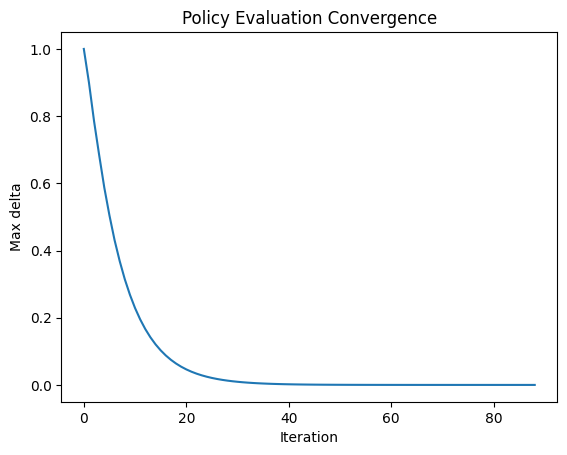

In [6]:

# Track the maximum update magnitude per iteration
plt.figure()
plt.plot(deltas_eval)
plt.xlabel("Iteration")
plt.ylabel("Max delta")
plt.title("Policy Evaluation Convergence")
plt.show()



## 5. Policy Iteration

Repeat until the policy stops changing:
1. **Policy Evaluation**: compute \(V^{\pi}\) for the current policy \(\pi\).  
2. **Policy Improvement**: make \(\pi\) greedy w.r.t. \(V^{\pi}\).  


In [7]:

def policy_improvement(P: dict, V: np.ndarray, gamma: float = 0.9) -> np.ndarray:
    """One greedy improvement step from V (returns a deterministic policy)."""
    return greedy_policy_from_V(P, V, gamma)

def policy_iteration(P: dict, gamma: float = 0.9,
                     theta: float = 1e-6, max_eval_iter: int = 10_000,
                     max_pi_iter: int = 1_000) -> tuple[np.ndarray, np.ndarray, int]:
    """Policy iteration: returns (optimal policy, optimal values, #improvement steps)."""
    S = len(P)
    # Start from a random deterministic policy (terminals get a dummy action 0)
    pi = np.random.randint(0, 4, size=S)
    pi[0] = 0; pi[S - 1] = 0

    for it in range(max_pi_iter):
        # Evaluate current policy
        V, _ = evaluate_policy(P, pi, gamma=gamma, theta=theta, max_iter=max_eval_iter)
        # Greedy improvement
        pi_new = policy_improvement(P, V, gamma=gamma)
        # Converged if the policy no longer changes
        if np.array_equal(pi, pi_new):
            return pi_new, V, it + 1
        pi = pi_new

    # Reached iteration cap (unlikely on this small MDP)
    return pi, V, max_pi_iter

pi_opt, V_opt, pi_steps = policy_iteration(P, gamma=gamma)
render_policy(pi_opt, title="Optimal Policy (Policy Iteration)")
render_values(V_opt, title="Optimal Values (Policy Iteration)")
print(f"Policy iteration improvement steps: {pi_steps}")


16
16
16
16
Optimal Policy (Policy Iteration)
T < < v
^ ^ ^ v
^ ^ > v
^ > > T

Optimal Values (Policy Iteration)
  0.00   0.00  -1.00  -1.90
  0.00  -1.00  -1.90  -1.00
 -1.00  -1.90  -1.00   0.00
 -1.90  -1.00   0.00   0.00

Policy iteration improvement steps: 4



## 6. Value Iteration

Apply **Bellman optimality** updates directly to \(V\):  
\[
V_{k+1}(s) \leftarrow \max_a \sum_{s'} P(s'\mid s,a)\,[\,R(s,a,s') + \gamma V_k(s')\,] .
\]  
After convergence, extract the optimal policy via `greedy_policy_from_V`.


In [8]:

def value_iteration(P: dict, gamma: float = 0.9,
                    theta: float = 1e-6, max_iter: int = 10_000) -> tuple[np.ndarray, np.ndarray, list[float]]:
    """Value iteration: returns (optimal policy, optimal values, deltas per iteration)."""
    S = len(P)
    V = np.zeros(S, dtype=float)
    deltas: list[float] = []
    for _ in range(max_iter):
        delta = 0.0
        V_new = V.copy()
        for s in range(S):
            if s == 0 or s == S - 1:   # terminals have value 0
                V_new[s] = 0.0
                continue
            # Compute q(s,a) for all actions and take the max
            best = -np.inf
            for a in range(4):
                q = 0.0
                for prob, s2, r, done in P[s][a]:
                    q += prob * (r + gamma * V[s2])
                if q > best:
                    best = q
            V_new[s] = best
            delta = max(delta, abs(best - V[s]))
        V = V_new
        deltas.append(delta)
        if delta < theta:              # convergence
            break
    # Greedy policy from final V
    pi = greedy_policy_from_V(P, V, gamma=gamma)
    return pi, V, deltas

pi_vi, V_vi, deltas_vi = value_iteration(P, gamma=gamma)
render_policy(pi_vi, title="Optimal Policy (Value Iteration)")
render_values(V_vi, title="Optimal Values (Value Iteration)")
print(f"Value iteration iterations: {len(deltas_vi)}, final max Δ={deltas_vi[-1]:.2e}")


Optimal Policy (Value Iteration)
T < < v
^ ^ ^ v
^ ^ > v
^ > > T

Optimal Values (Value Iteration)
  0.00   0.00  -1.00  -1.90
  0.00  -1.00  -1.90  -1.00
 -1.00  -1.90  -1.00   0.00
 -1.90  -1.00   0.00   0.00

Value iteration iterations: 3, final max Δ=0.00e+00


**Convergence of Value Iteration**

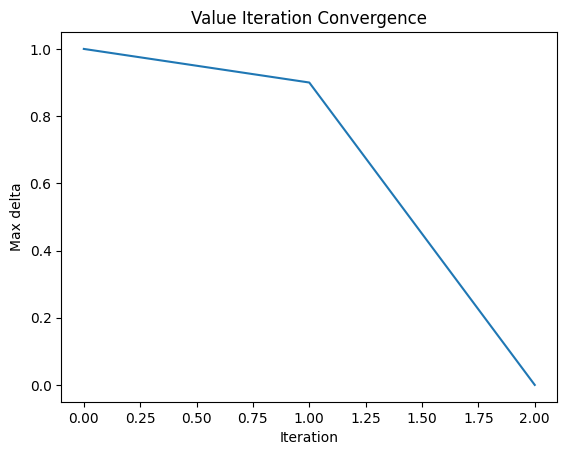

In [9]:

plt.figure()
plt.plot(deltas_vi)
plt.xlabel("Iteration")
plt.ylabel("Max delta")
plt.title("Value Iteration Convergence")
plt.show()



## 7. Notes & Tips

- Smaller `theta` (tolerance) yields more accurate values but may require more iterations.  
- Larger `gamma` (e.g., 0.99) emphasizes long-term rewards; value magnitudes typically grow.  
- You can turn this into a **stochastic** MDP by adding multiple `(prob, s', r, done)` outcomes in `P[s][a]`.  
- **Policy Iteration** often converges in a handful of improvement steps on small deterministic MDPs; **Value Iteration** is simple and amenable to parallelization on larger problems.
